In [81]:
!pip install opencv-python-headless tensorflow scikit-learn pandas matplotlib seaborn pillow -q

In [82]:
#Import Libraries

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.preprocessing.image import img_to_array


from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns

In [83]:
import os

os.makedirs("images", exist_ok=True)

In [84]:
#Check Dataset to confirm all team members' images exist.

image_folder="images"


files=os.listdir(image_folder)


image_files=[
    f for f in files
    if f.endswith((".jpg",".jpeg",".png"))
]


print(
    "Total images:",
    len(image_files)
)


for img in image_files:
    print(img)

Total images: 12
shalom_smile.jpeg
christian_smile.jpeg
hikma_surprised.jpeg
shalom_surprised.jpeg
mukasa_neutral.jpeg
shalom_neutral.jpeg
christian_surprised.jpeg
mukasa_surprised.jpeg
hikma_smile.jpeg
mukasa_smile.jpeg
christian_neutral.jpeg
hikma_neutral.jpeg


In [85]:
#Extract Labels
def extract_labels(filename):
    name=filename.split("_")[0]
    emotion=filename.split("_")[1].split(".")[0]
    return name,emotion

# Dataset Summary
data_summary=[]
for file in image_files:
    person,emotion=extract_labels(file)
    data_summary.append(
        {
            "Person":person,
            "Expression":emotion
        }
    )


summary_df=pd.DataFrame(data_summary)


print("Images per person:")
print(
summary_df["Person"].value_counts()
)


print("\nExpressions:")
print(
summary_df["Expression"].value_counts()
)

Images per person:
Person
shalom       3
christian    3
hikma        3
mukasa       3
Name: count, dtype: int64

Expressions:
Expression
smile        4
surprised    4
neutral      4
Name: count, dtype: int64


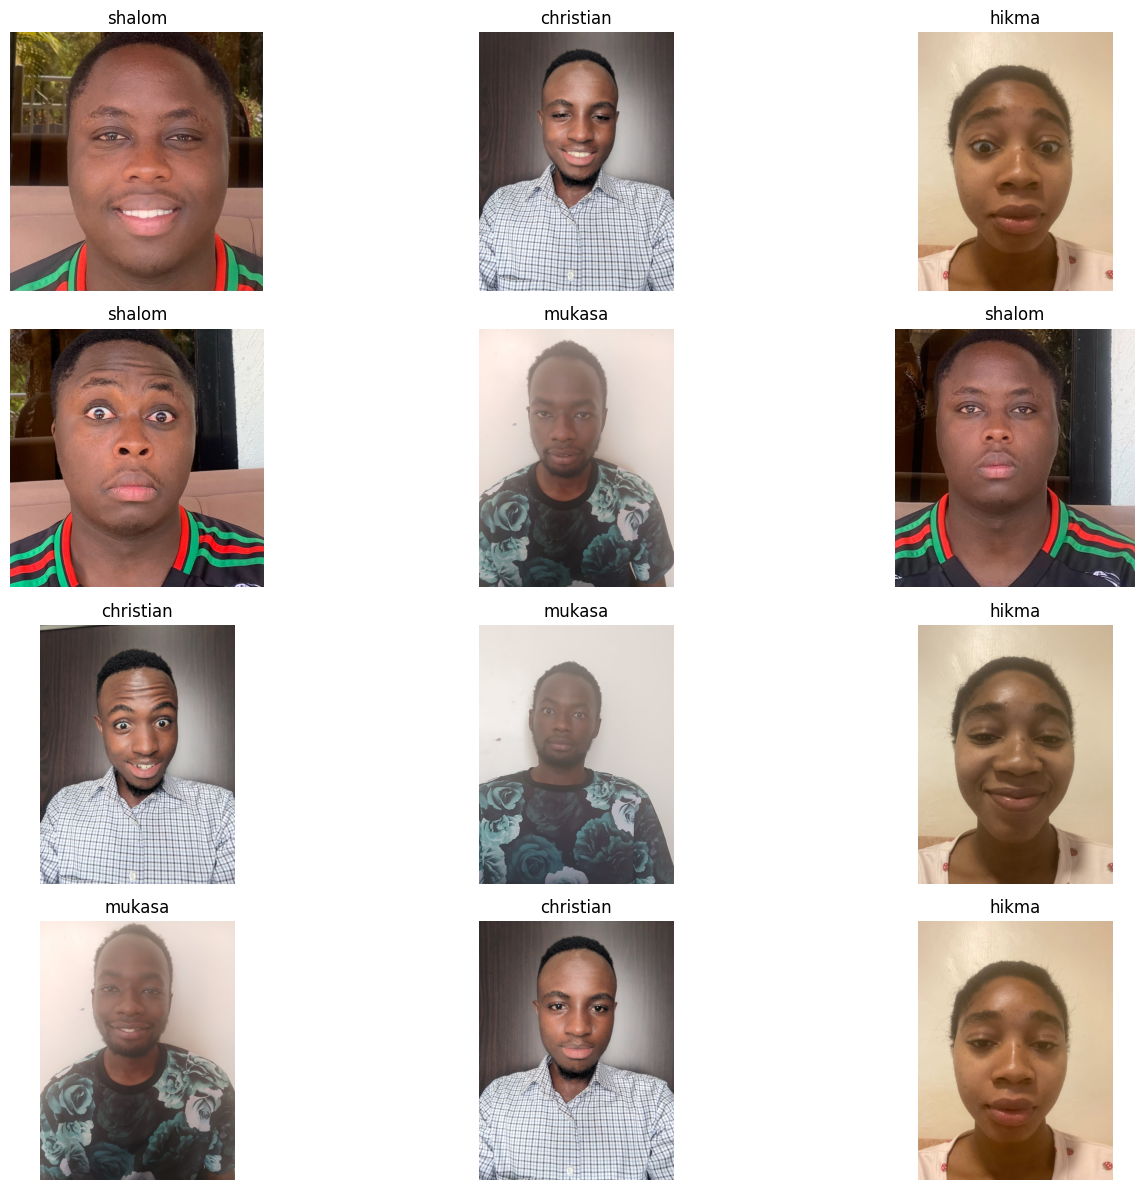

In [86]:
#Display ALL Members

plt.figure(figsize=(15,12))


for i,file in enumerate(image_files):

    img=cv2.imread(
        os.path.join(
            image_folder,
            file
        )
    )


    img=cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )


    plt.subplot(4,3,i+1)


    plt.imshow(img)

    plt.title(file.split("_")[0])

    plt.axis("off")


plt.tight_layout()

plt.show()

In [87]:
#Face Detection Model

face_detector=cv2.CascadeClassifier(
    cv2.data.haarcascades+
    "haarcascade_frontalface_default.xml"
)



def extract_face(image_path):

    img=cv2.imread(image_path)


    gray=cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )


    faces=face_detector.detectMultiScale(
        gray,
        1.1,
        5
    )


    if len(faces)==0:

        return None


    x,y,w,h=faces[0]


    face=img[
        y:y+h,
        x:x+w
    ]


    face=cv2.resize(
        face,
        (224,224)
    )


    return face

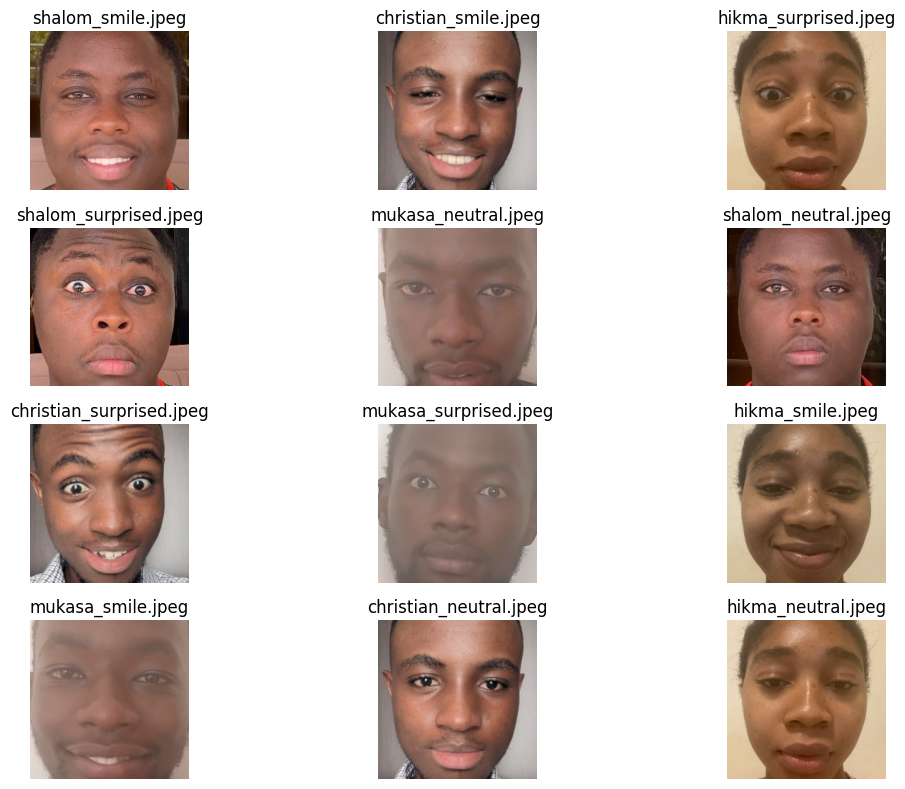

In [88]:
#Test Face Extraction For Everyone

plt.figure(figsize=(12,8))


for i,file in enumerate(image_files):


    face=extract_face(
        os.path.join(
            "images",
            file
        )
    )


    if face is not None:


        plt.subplot(4,3,i+1)

        plt.imshow(
            cv2.cvtColor(
                face,
                cv2.COLOR_BGR2RGB
            )
        )


        plt.title(file)

        plt.axis("off")


plt.tight_layout()

plt.show()

In [89]:
#Draw a Face Bounding Boxes

def show_detected_faces(image_path):

    img=cv2.imread(image_path)


    gray=cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )


    faces=face_detector.detectMultiScale(
        gray,
        1.1,
        5
    )


    for x,y,w,h in faces:

        cv2.rectangle(
            img,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            3
        )


    plt.figure(figsize=(4,4))


    plt.imshow(
        cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )
    )


    plt.axis("off")

    plt.show()

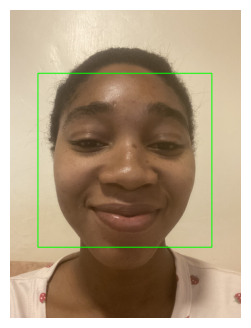

In [90]:
show_detected_faces(
"images/hikma_smile.jpeg"
)

In [91]:
#Image Augmentation

def augment_image(img):


    augmented={}


    augmented["original"]=img


    # rotation

    matrix=cv2.getRotationMatrix2D(
        (112,112),
        20,
        1
    )


    rotated=cv2.warpAffine(
        img,
        matrix,
        (224,224)
    )


    augmented["rotation_20"]=rotated




    # flip

    flipped=cv2.flip(
        img,
        1
    )


    augmented["flip"]=flipped



    # grayscale

    gray=cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )


    gray=cv2.cvtColor(
        gray,
        cv2.COLOR_GRAY2BGR
    )


    augmented["gray"]=gray



    # brightness


    bright=cv2.convertScaleAbs(
        img,
        alpha=1.3,
        beta=30
    )


    augmented["brightness"]=bright



    # Additional rotation
    matrix2=cv2.getRotationMatrix2D(
        (112,112),
        -20,
        1
    )


    rotated2=cv2.warpAffine(
        img,
        matrix2,
        (224,224)
    )


    augmented["rotation_-20"]=rotated2

    # Add noise
    noise=np.random.normal(
        0,
        15,
        img.shape
    )


    noisy=img+noise


    noisy=np.clip(
        noisy,
        0,
        255
    ).astype(np.uint8)


    augmented["noise"]=noisy



    return augmented

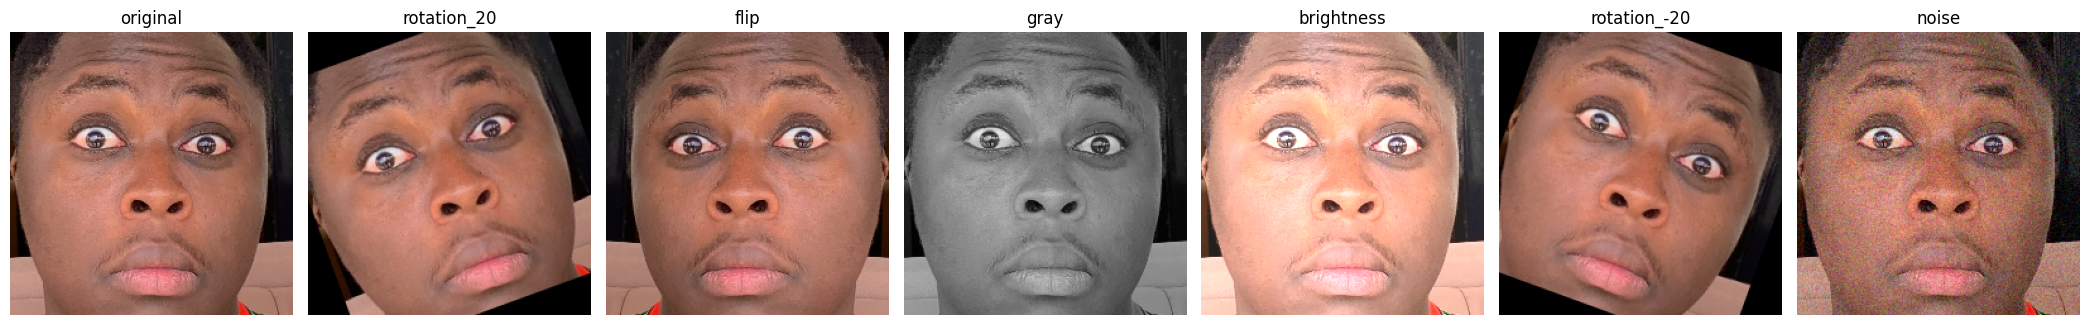

In [92]:
#Test Augmentation

face=extract_face(
    "images/shalom_surprised.jpeg"
)


augmented=augment_image(face)



num_augmented_images = len(augmented)
plt.figure(figsize=(num_augmented_images * 3, 5)) # Adjust figure size dynamically


for i,(name,img) in enumerate(
    augmented.items()
):


    plt.subplot(1, num_augmented_images, i+1) # Dynamically adjust subplot columns


    plt.imshow(
        cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )
    )


    plt.title(name)

    plt.axis("off")


plt.tight_layout()
plt.show()

In [93]:
#MobileNetV2 Feature Extractor
#Instead of training CNN from scratch, we use transfer learning.

cnn=MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224,224,3)
)

In [94]:
#Create Embeddings

def create_embedding(img):


    img=img_to_array(img)


    img=np.expand_dims(
        img,
        axis=0
    )


    img=preprocess_input(img)



    embedding=cnn.predict(
        img,
        verbose=0
    )


    return embedding.flatten()

In [95]:
#An example can be

extract_labels(
"hikma_smile.jpeg"
)

('hikma', 'smile')

In [96]:
#Create image_features.csv

records=[]



for file in image_files:


    person,emotion=extract_labels(file)


    path=os.path.join(
        "images",
        file
    )


    face=extract_face(path)



    if face is None:
        continue



    augmented=augment_image(face)



    for aug_name,img in augmented.items():


        embedding=create_embedding(img)



        row={

            "person":person,

            "emotion":emotion,

            "augmentation":aug_name

        }



        for i,value in enumerate(embedding):

            row[
            f"feature_{i}"
            ]=value



        records.append(row)



df=pd.DataFrame(records)



df.to_csv(
"image_features.csv",
index=False
)


print(df.shape)

df.head()

(84, 1283)


,person,emotion,augmentation,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_1270,feature_1271,feature_1272,feature_1273,feature_1274,feature_1275,feature_1276,feature_1277,feature_1278,feature_1279
0,shalom,smile,original,1.572792,0.088450,0.0,0.351693,0.0,0.000000,0.402310,...,0.063275,0.044450,0.904519,0.469268,0.000000,0.239333,0.0,0.480251,0.797342,0.423984
1,shalom,smile,rotation_20,1.237351,0.246305,0.0,1.216320,0.0,0.665198,0.031537,...,1.423038,0.000000,0.183265,0.605956,0.000000,0.000000,0.0,0.070599,0.512119,1.903008
2,shalom,smile,flip,1.164279,0.206009,0.0,0.276840,0.0,0.053433,0.319379,...,0.130165,0.052062,0.446466,0.870475,0.006614,0.135408,0.0,0.307852,0.822119,0.370600
3,shalom,smile,gray,0.758475,0.008821,0.0,0.302712,0.0,0.286608,0.057437,...,0.000000,0.304420,2.831127,0.441427,0.000000,0.176816,0.0,0.047316,1.054794,0.210320
4,shalom,smile,brightness,1.322049,0.304492,0.0,0.357250,0.0,0.000000,0.270361,...,0.028265,0.035499,0.839672,1.049932,0.000000,0.313581,0.0,0.303814,0.793011,0.371053


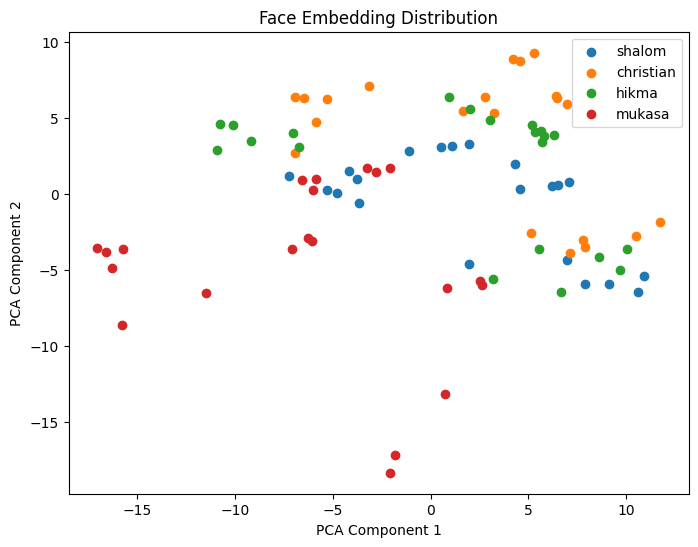

In [97]:
from sklearn.decomposition import PCA


features=df.drop(
[
"person",
"emotion",
"augmentation"
],
axis=1
)



pca=PCA(
n_components=2
)


reduced=pca.fit_transform(features)



plt.figure(figsize=(8,6))


for person in df["person"].unique():

    indices=df["person"]==person


    plt.scatter(
        reduced[indices,0],
        reduced[indices,1],
        label=person
    )


plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.title(
"Face Embedding Distribution"
)


plt.legend()

plt.show()

In [98]:
#Dataset Split

print("Feature dataset size:")
print(df.shape)


print("\nClasses detected:")
print(df["person"].unique())


print("\nSamples per person:")
print(
df["person"].value_counts()
)

Feature dataset size:
(84, 1283)

Classes detected:
['shalom' 'christian' 'hikma' 'mukasa']

Samples per person:
person
shalom       21
christian    21
hikma        21
mukasa       21
Name: count, dtype: int64


In [99]:
#Train Face Recognition Model

X=df.drop(
    [
    "person",
    "emotion",
    "augmentation"
    ],
    axis=1
)



y=df["person"]



X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)



model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [100]:
import pickle


with open(
"face_recognition_model.pkl",
"wb"
) as file:

    pickle.dump(
        model,
        file
    )


print(
"Model saved successfully"
)

Model saved successfully


In [101]:
#Evaluate Model

pred=model.predict(
    X_test
)



accuracy=accuracy_score(
    y_test,
    pred
)


print(
"Accuracy:",
accuracy
)


print(
classification_report(
    y_test,
    pred
)
)

Accuracy: 1.0
              precision    recall  f1-score   support

   christian       1.00      1.00      1.00         4
       hikma       1.00      1.00      1.00         4
      mukasa       1.00      1.00      1.00         5
      shalom       1.00      1.00      1.00         4

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



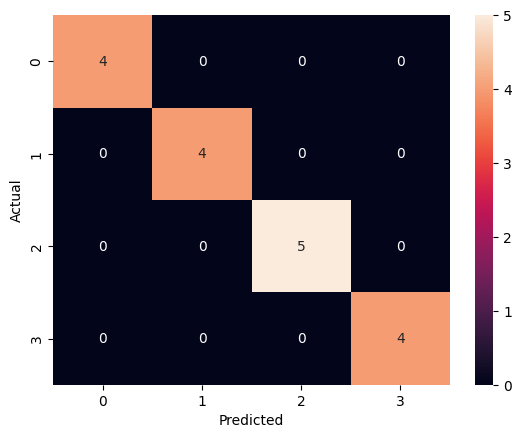

In [102]:
#Confusion Matrix

cm=confusion_matrix(
    y_test,
    pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
"Predicted"
)


plt.ylabel(
"Actual"
)


plt.show()

In [103]:
import os

os.makedirs("test_images", exist_ok=True)

In [104]:
import os

print(os.listdir("test_images"))

['stranger.jpg']


In [105]:
#Test the exact path

import os

test_path="test_images/stranger.jpg"


print(
    os.path.exists(test_path)
)

True


In [106]:
#REAL AUTHENTICATION DEMO

def authenticate(test_path):


    print("Testing image:", test_path)



    if not os.path.exists(test_path):

        print("ERROR: Image does not exist")

        return



    face=extract_face(test_path)



    if face is None:

        print(
        "No face detected"
        )

        return



    print("Face detected successfully")



    embedding=create_embedding(face)



    prediction=model.predict(
        [embedding]
    )[0]



    probability=max(
        model.predict_proba(
            [embedding]
        )[0]
    )



    print(
        "Prediction:",
        prediction
    )


    print(
        "Confidence:",
        round(probability,3)
    )



    if probability > 0.70:


        print(
        "ACCESS GRANTED"
        )


    else:

        print(
        "ACCESS DENIED"
        )


In [107]:
#Test Hikma first

authenticate(
"images/hikma_smile.jpeg"
)

Testing image: images/hikma_smile.jpeg
Face detected successfully
Prediction: hikma
Confidence: 0.88
ACCESS GRANTED


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [108]:
#Test Unknown person

authenticate(
"test_images/stranger.jpg"
)

Testing image: test_images/stranger.jpg
Face detected successfully
Prediction: mukasa
Confidence: 0.33
ACCESS DENIED


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
